In [43]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2
from imports import *


In [44]:
from config import dir_config
from src.utils import pmf_utils, classification_utils

raw_dir = Path(dir_config.data.raw)
processed_dir = Path(dir_config.data.processed)

filtered_data = pd.read_csv(Path(processed_dir, "processed_all_data_accu_60_filtered.csv"), index_col=None)
processed_metadata = pd.read_csv(Path(processed_dir, "processed_metadata_all_data_accu_60.csv"), index_col=None)


In [45]:
subjects_map, grp_indices = classification_utils.get_subject_classification_ids(processed_metadata)

PD subjects with ON+OFF sessions: 41
PD subjects with UPDRS subtype: 22
All PD subjects:           41
  Tremor dominant:         11 	 ['P3' 'P6' 'P7' 'P11' 'P12' 'P17' 'P18' 'P19' 'P29' 'P31' 'P32']
  Brady dominant:          10 	 ['P1' 'P4' 'P9' 'P13' 'P20' 'P22' 'P23' 'P28' 'P33' 'P34']
  Intermediate:            1 	 ['P24']
HC subjects:               18 	 ['HC1' 'HC3' 'HC6' 'HC7' 'HC8' 'HC9' 'HC12' 'HC13' 'AV' 'BC' 'BF' 'EM'
 'ES' 'GF' 'GP' 'JA' 'MRM' 'SY']


In [46]:
def new_accumulators():
    """Empty accumulators for positive-prior and equal-prior psychometric data."""
    return {k: {"coh": [], "psych": [], "model": [], "x_hat": [], "y_hat": []} for k in ("pos", "eq")}


def collect_psych(data, accum):
    """Fit psychometric data for both color conditions and append to accum."""
    for key, color_val in [("pos", 1), ("eq", 0)]:
        coh, psych, model, x_hat, y_hat = pmf_utils.get_psychometric_data(data[data["color"] == color_val])
        for field, val in zip(["coh", "psych", "model", "x_hat", "y_hat"], [coh, psych, model, x_hat, y_hat]):
            accum[key][field].append(val)


def plot_mean_psych(ax, accum, pos_color, eq_color, err_style):
    """Plot group-mean psychometric curve with error bars and fitted line."""
    for key, color, label in [("pos", pos_color, "Positive Prior"), ("eq", eq_color, "Equal Prior")]:
        coh_arr = np.array(accum[key]["coh"])
        psych_arr = np.array(accum[key]["psych"])
        x_hat_arr = np.array(accum[key]["x_hat"])
        mean_coh, mean_psych = np.mean(coh_arr, axis=0), np.mean(psych_arr, axis=0)
        mean_x_hat = np.mean(x_hat_arr, axis=0)
        ax.plot(mean_coh, mean_psych, color=color, ls="", marker="o", ms=12, mec="k", label=label)
        ax.errorbar(mean_coh, mean_psych, yerr=stats.sem(psych_arr, axis=0), color=color, ls="", marker="o", ms=12, mec="k", **err_style)
        fit = pmf_utils.fit_psychometric_function(mean_coh, mean_psych, trial_counts=None, model_type="logit_4")
        ax.plot(mean_x_hat, fit.predict(mean_x_hat), color=color, ls="-", lw=4)


In [47]:
psych_columns = [
    "positive_psych_alpha",
    "positive_psych_beta",
    "equal_psych_alpha",
    "equal_psych_beta",
    "positive_bias",
    "equal_bias",
]

psych_params = processed_metadata[psych_columns]


In [48]:
from src.utils.stats_utils import wilcoxon_battery

pos_color, eq_color = "#C2B39F", "#8C5A96"
alpha = 0.08
err_style = {"elinewidth": 2, "capsize": 10, "capthick": 2}


def panel_bias_rows(grp, sub_ids=None):
    """Psych params for `grp`, restricted to `sub_ids` (the subjects a panel actually draws)."""
    idx = pd.Index(grp_indices[grp])
    if sub_ids is not None:
        idx = idx[processed_metadata.loc[idx, "subject_id"].isin(list(sub_ids))]
    return psych_params.loc[idx]


def bias_significance(panels):
    """Bonferroni-corrected p-value (positive vs equal bias) per panel, jointly across `panels`.

    Items are panel dicts (keyed by "title", so two panels sharing a group but drawing
    different subject subsets each get their own test) or a bare group name.
    """
    tests = {}
    for panel in panels:
        if isinstance(panel, str):
            key, group_data = panel, panel_bias_rows(panel)
        else:
            key, group_data = panel["title"], panel_bias_rows(panel["grp"], panel["sub_ids"])
        tests[key] = (group_data["positive_bias"], group_data["equal_bias"])
    return wilcoxon_battery(tests=tests, print_results=False).set_index("test")["corrected_p"]


def plot_curve_bias_panel(ax, sub_ids, med, grp, title, letter, p_value, inset_ylim):
    """Plot one psychometric-curve panel, with a bottom-right inset bias bar chart, onto `ax`."""
    # ── curves ──
    accum = new_accumulators()
    for sid in sub_ids:
        subj_data = filtered_data[filtered_data["subject_id"] == sid]
        if med is not None:
            subj_data = subj_data[subj_data["medication"] == med]
        if subj_data.empty:
            continue
        collect_psych(subj_data, accum)

    for key, color in [("pos", pos_color), ("eq", eq_color)]:
        for coh, psych, x_hat, y_hat in zip(accum[key]["coh"], accum[key]["psych"], accum[key]["x_hat"], accum[key]["y_hat"]):
            ax.plot(coh, psych, color=color, marker="o", ls="", alpha=alpha)
            ax.plot(x_hat, y_hat, color=color, ls="-", alpha=alpha)

    plot_mean_psych(ax, accum, pos_color, eq_color, err_style)

    ax.axhline(0.5, color="0.6", ls="--", lw=1.5, zorder=0)
    ax.axvline(0, color="0.6", ls="--", lw=1.5, zorder=0)

    # ── inset bias bar chart (bottom-right, clear of the curve) ──
    inset_rect = [0.68, 0.06, 0.28, 0.30]
    bg_rect = plt.Rectangle(
        (inset_rect[0], inset_rect[1]),
        inset_rect[2],
        inset_rect[3],
        transform=ax.transAxes,
        facecolor="white",
        edgecolor="none",
        zorder=4,
    )
    ax.add_patch(bg_rect)
    ax_ins = ax.inset_axes(inset_rect)
    ax_ins.set_zorder(5)

    group_data = panel_bias_rows(grp, sub_ids)
    eq_vals = (group_data["equal_bias"] - 0.5).values
    pos_vals = (group_data["positive_bias"] - 0.5).values

    bar_tops = []
    for xi, (vals, color) in enumerate([(eq_vals, eq_color), (pos_vals, pos_color)]):
        mean, sem = np.mean(vals), stats.sem(vals)
        ax_ins.bar(xi, mean, color=color, edgecolor="k", linewidth=0.8, width=0.6)
        ax_ins.errorbar(xi, mean, yerr=sem, fmt="none", color="k", capsize=4, elinewidth=1.2, capthick=1.2)
        bar_tops.append(mean + sem)

    if p_value < 0.05:
        star = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*"
        ax_ins.text(0.5, max(bar_tops) + 0.015, star, ha="center", va="bottom", fontsize=16, fontweight="bold")

    ax_ins.set_xticks([])
    ax_ins.set_ylim(*inset_ylim)
    ax_ins.set_ylabel("Bias", fontsize=14)
    ax_ins.tick_params(labelsize=10)
    for sp in ["top", "right"]:
        ax_ins.spines[sp].set_visible(False)

    # ── panel styling ──
    ax.set_xticks([-100, -35, -13, 0, 13, 35, 100])
    ax.tick_params(labelsize=15)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    ax.set_xlim(-105, 105)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Orientation Strength (% Coherence)", fontsize=18)
    ax.text(0.03, 0.94, f"N = {len(sub_ids)}", transform=ax.transAxes, fontsize=18, va="top")
    ax.set_title(rf"$\mathbf{{{letter}}}$   {title}", loc="left", fontsize=18)


## Combined psychometric + bias summary figure

In [49]:
subjects_map


{'healthy': array(['HC1', 'HC3', 'HC6', 'HC7', 'HC8', 'HC9', 'HC12', 'HC13', 'AV',
        'BC', 'BF', 'EM', 'ES', 'GF', 'GP', 'JA', 'MRM', 'SY'],
       dtype=object),
 'all': array(['P1', 'P3', 'P4', 'P6', 'P7', 'P9', 'P11', 'P12', 'P13', 'P17',
        'P18', 'P19', 'P20', 'P22', 'P23', 'P24', 'P28', 'P29', 'P31',
        'P32', 'P33', 'P34', 'CG', 'COH', 'MBY', 'DP', 'FUR', 'LBR', 'MAR',
        'SMI', 'PAM', 'RW', 'BBK', 'BER', 'DCAM', 'ALE', 'DMO', 'RBA',
        'RDE', 'SGA', 'LHO'], dtype=object),
 'tremor_dominant': array(['P3', 'P6', 'P7', 'P11', 'P12', 'P17', 'P18', 'P19', 'P29', 'P31',
        'P32'], dtype=object),
 'bradykinesia_dominant': array(['P1', 'P4', 'P9', 'P13', 'P20', 'P22', 'P23', 'P28', 'P33', 'P34'],
       dtype=object)}

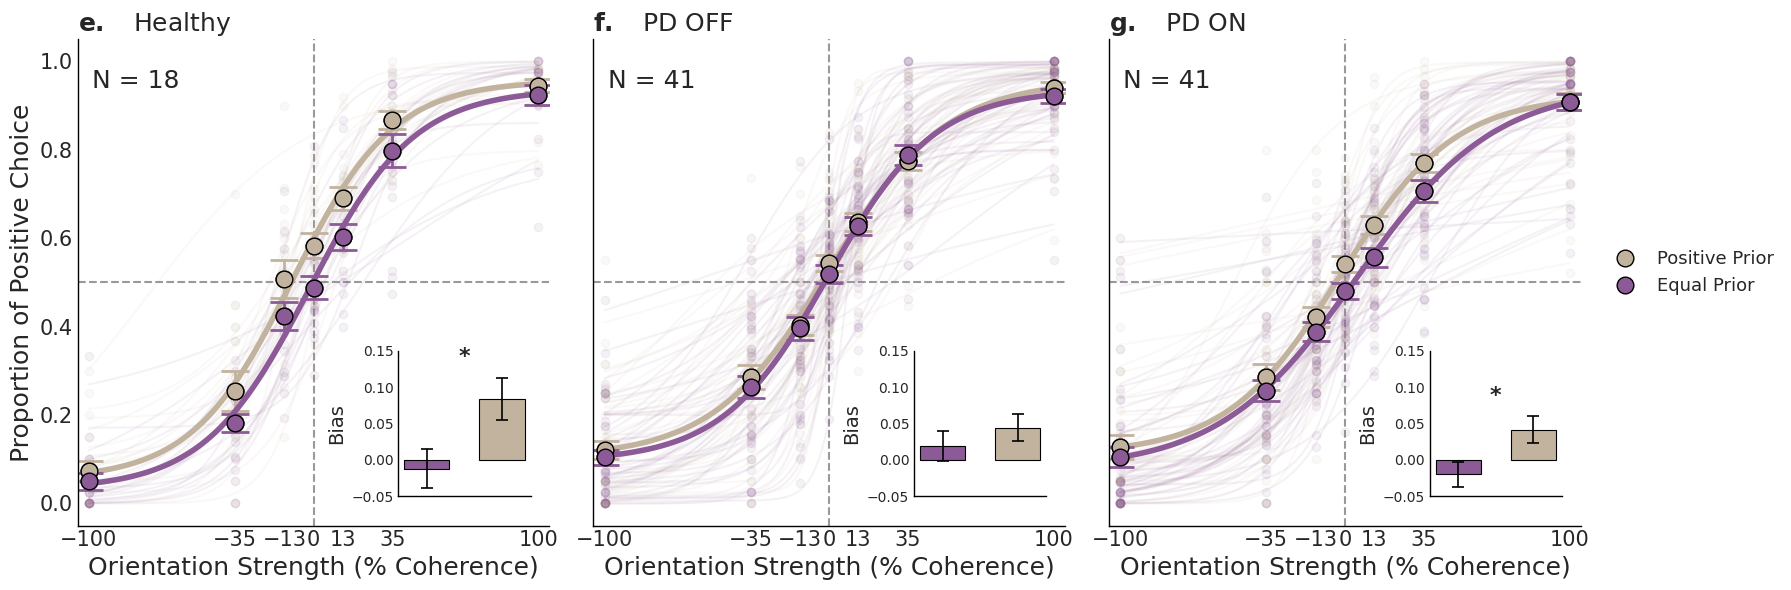

In [50]:
main_panels = [
    {"grp": "healthy", "sub_ids": subjects_map["healthy"], "med": None, "title": "Healthy"},
    {"grp": "pd_off", "sub_ids": subjects_map["all"], "med": "off", "title": "PD OFF"},
    {"grp": "pd_on", "sub_ids": subjects_map["all"], "med": "on", "title": "PD ON"},
]
main_letters = ["e.", "f.", "g."]
main_corrected_p = bias_significance(main_panels)

fig, axes = plt.subplots(1, len(main_panels), figsize=(18, 6), sharey=True)
for ax, panel, letter in zip(axes, main_panels, main_letters):
    plot_curve_bias_panel(
        ax,
        panel["sub_ids"],
        panel["med"],
        panel["grp"],
        panel["title"],
        letter,
        main_corrected_p[panel["title"]],
        inset_ylim=(-0.05, 0.15),
    )

axes[0].set_ylabel("Proportion of Positive Choice", fontsize=18)
axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 0.60), fontsize=13, frameon=False)
fig.tight_layout()


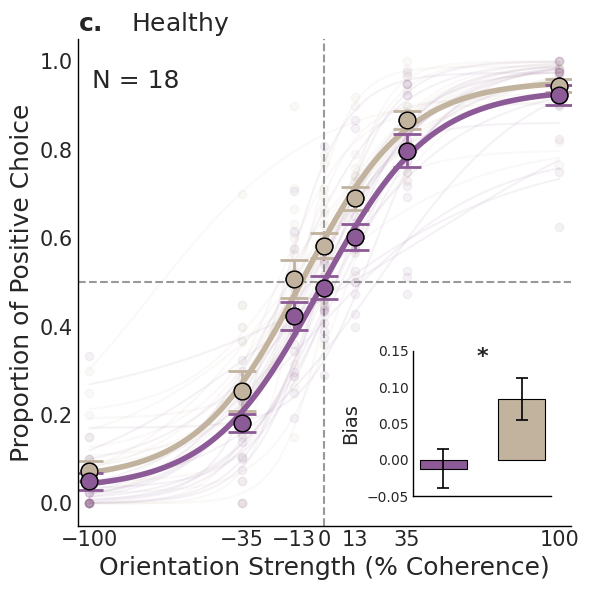

In [51]:
main_panels = {"grp": "healthy", "sub_ids": subjects_map["healthy"], "med": None, "title": "Healthy"}

main_letters = "c."
main_corrected_p = bias_significance([main_panels])

fig, axes = plt.subplots(1, 1, figsize=(6, 6), sharey=True)
axes = [axes]
# for ax, panel, letter in zip(axes, main_panels, main_letters):
plot_curve_bias_panel(
    axes[0],
    main_panels["sub_ids"],
    main_panels["med"],
    main_panels["grp"],
    main_panels["title"],
    main_letters,
    main_corrected_p[main_panels["title"]],
    inset_ylim=(-0.05, 0.15),
)

axes[0].set_ylabel("Proportion of Positive Choice", fontsize=18)
# axes[0].legend(loc="upper left", bbox_to_anchor=(1.02, 0.60), fontsize=13, frameon=False)
fig.tight_layout()


In [52]:
filtered_data.head()

,subject_id,group,medication,prior,prior_direction,prior_color,color,coherence,target,is_valid,outcome,choice,reaction_time,session_filename,signed_coherence,session_id
0,HC6,hc,NaN,gl,left,green,1,35.0,1,True,1.0,1,1131.517634,HC6_healthy_gl.mat,35.0,HC6
1,HC6,hc,NaN,gl,left,green,0,35.0,1,True,1.0,1,788.931217,HC6_healthy_gl.mat,35.0,HC6
2,HC6,hc,NaN,gl,left,green,1,13.0,1,True,0.0,0,1192.128380,HC6_healthy_gl.mat,13.0,HC6
3,HC6,hc,NaN,gl,left,green,1,0.0,0,True,0.0,1,1589.536018,HC6_healthy_gl.mat,-0.0,HC6
4,HC6,hc,NaN,gl,left,green,1,100.0,0,True,1.0,0,781.757934,HC6_healthy_gl.mat,-100.0,HC6


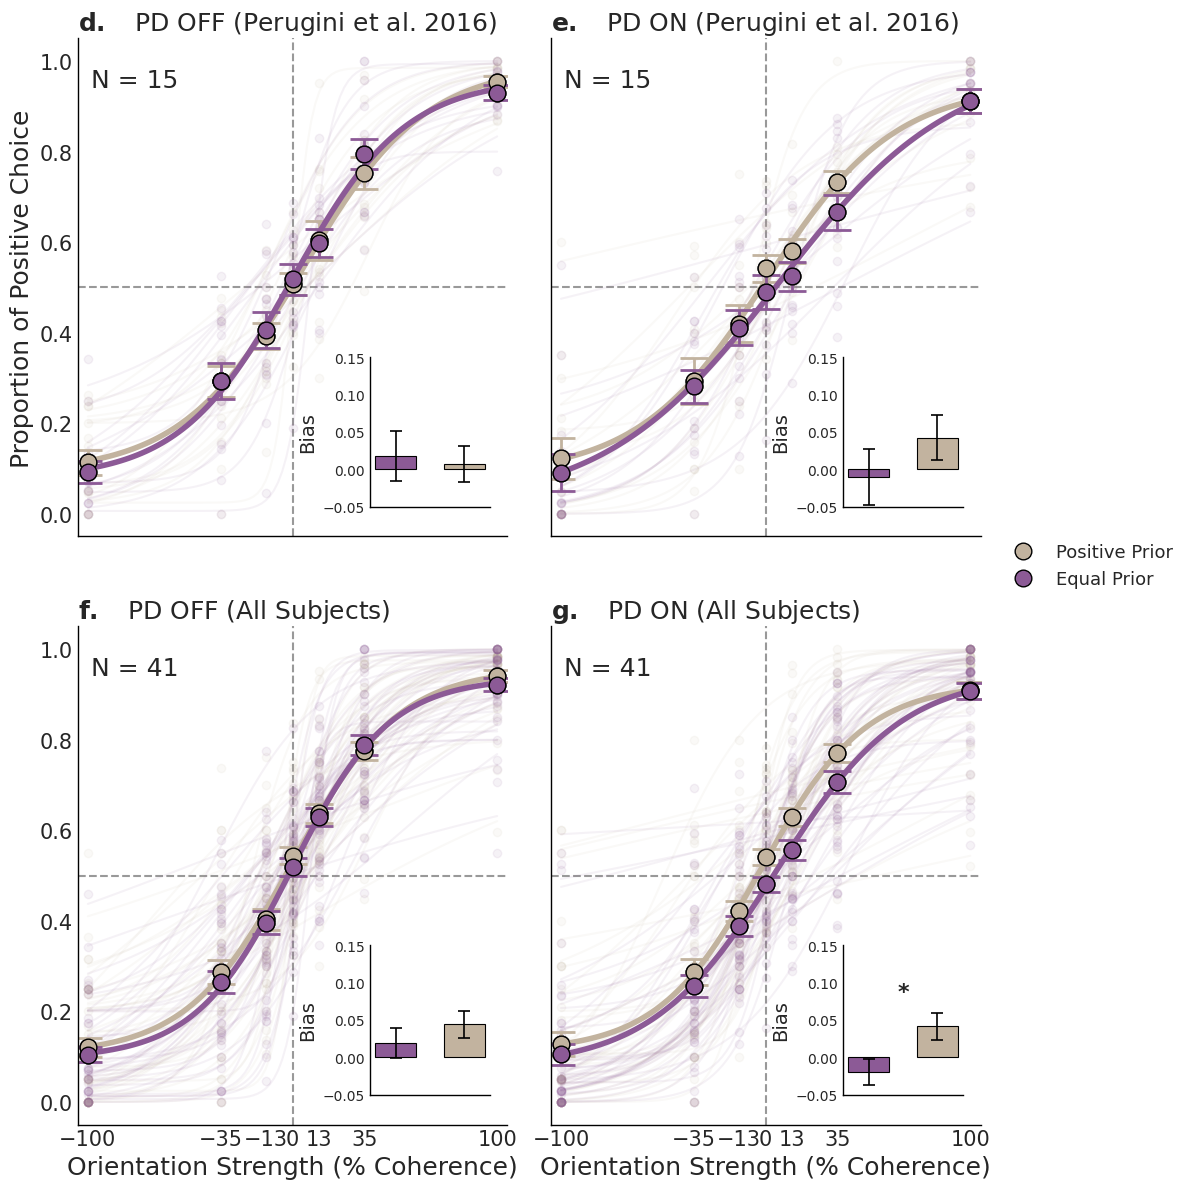

In [ ]:
ucla_pd = set(processed_metadata[(processed_metadata["experiment_site"] == "UCLA") & (processed_metadata["is_pd"] == 1)]["subject_id"].unique())


main_panels = [
    {"grp": "pd_off", "sub_ids": ucla_pd, "med": "off", "title": "PD OFF (Perugini et al. 2016)"},
    {"grp": "pd_on", "sub_ids": ucla_pd, "med": "on", "title": "PD ON (Perugini et al. 2016)"},
    {"grp": "pd_off", "sub_ids": subjects_map["all"], "med": "off", "title": "PD OFF (All Subjects)"},
    {"grp": "pd_on", "sub_ids": subjects_map["all"], "med": "on", "title": "PD ON (All Subjects)"},
]
main_letters = ["d.", "e.", "f.", "g."]
main_corrected_p = bias_significance(main_panels)

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)
axes = axes.flatten()
for ax, panel, letter in zip(axes, main_panels, main_letters):
    plot_curve_bias_panel(
        ax,
        panel["sub_ids"],
        panel["med"],
        panel["grp"],
        panel["title"],
        letter,
        main_corrected_p[panel["title"]],
        inset_ylim=(-0.05, 0.15),
    )

axes[0].set_ylabel("Proportion of Positive Choice", fontsize=18)
for i in [0, 1]:
    axes[i].set_xticklabels([])
    axes[i].set_xlabel("")
axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.2), fontsize=13, frameon=False)
fig.tight_layout()


## Combined psychometric + bias summary figure — Tremor vs Bradykinesia subtypes

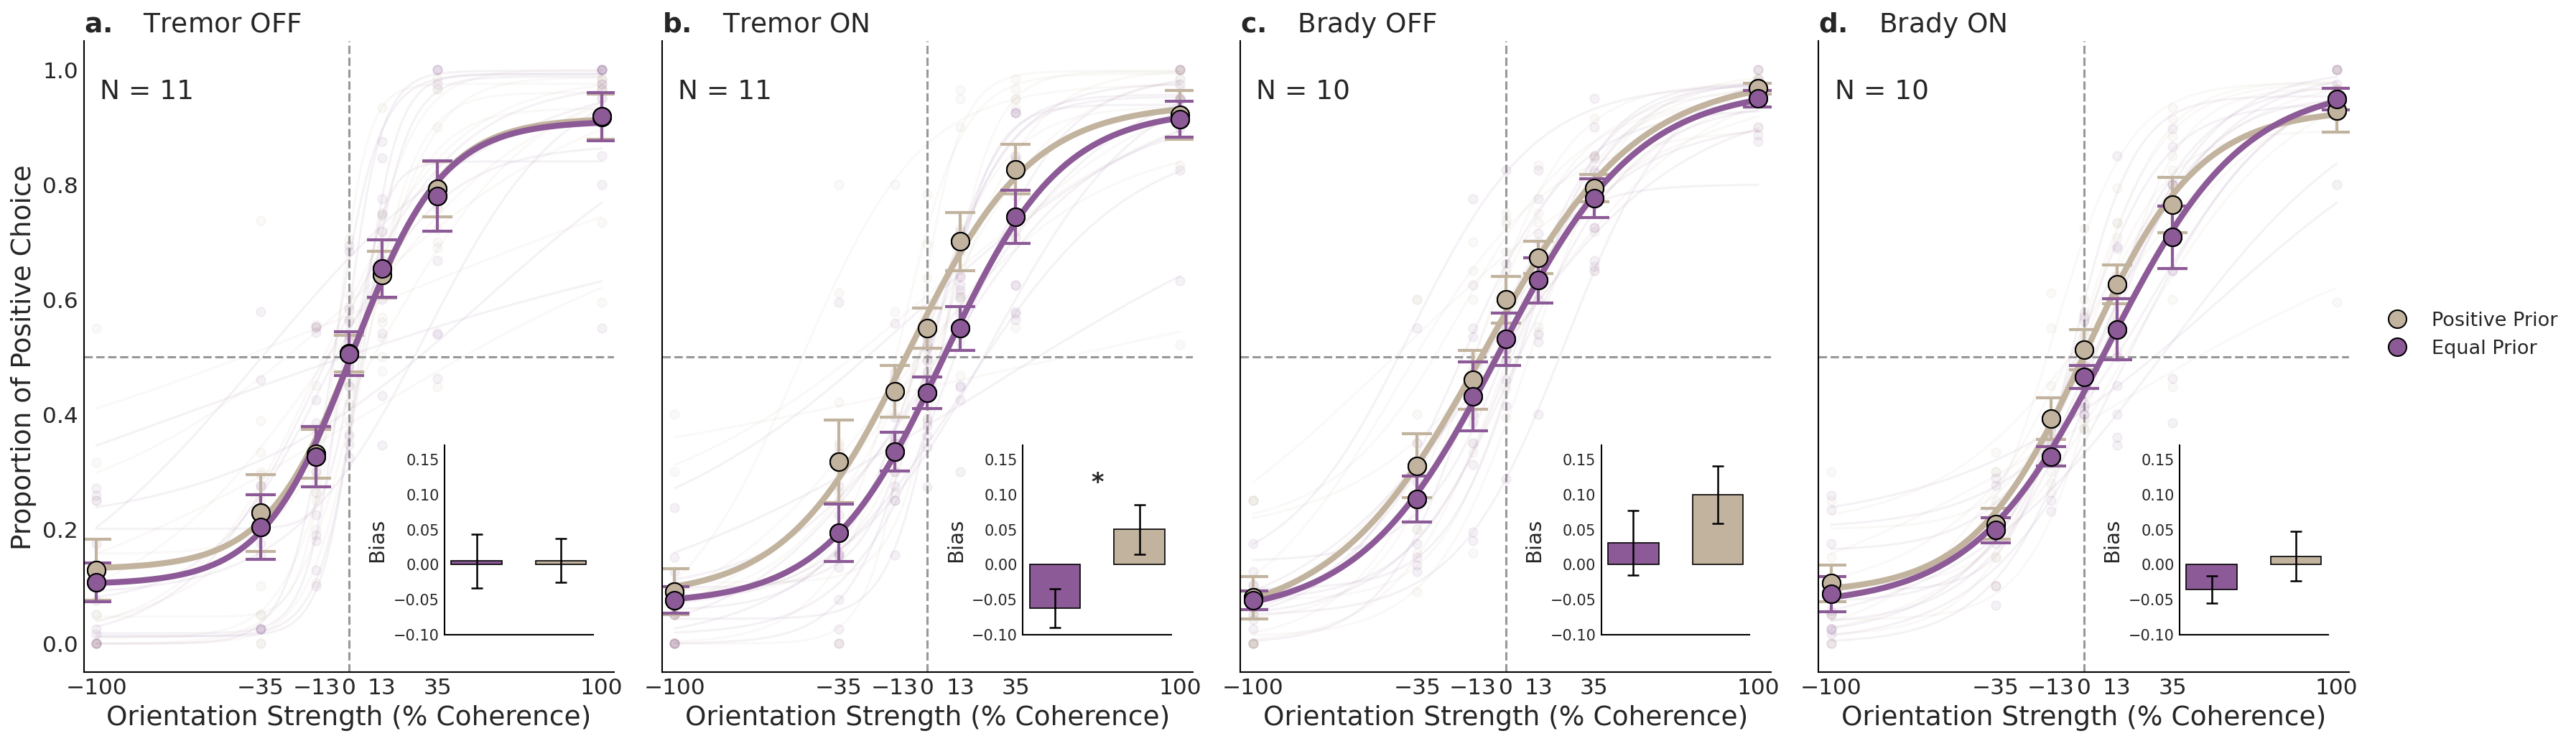

In [8]:
subtype_panels = [
    {"grp": "tremor_off", "sub_ids": subjects_map["tremor_dominant"], "med": "off", "title": "Tremor OFF"},
    {"grp": "tremor_on", "sub_ids": subjects_map["tremor_dominant"], "med": "on", "title": "Tremor ON"},
    {"grp": "brady_off", "sub_ids": subjects_map["bradykinesia_dominant"], "med": "off", "title": "Brady OFF"},
    {"grp": "brady_on", "sub_ids": subjects_map["bradykinesia_dominant"], "med": "on", "title": "Brady ON"},
]
subtype_letters = ["a.", "b.", "c.", "d."]
subtype_corrected_p = bias_significance(subtype_panels)

fig, axes = plt.subplots(1, len(subtype_panels), figsize=(24, 7), sharey=True)
for ax, panel, letter in zip(axes, subtype_panels, subtype_letters):
    plot_curve_bias_panel(
        ax,
        panel["sub_ids"],
        panel["med"],
        panel["grp"],
        panel["title"],
        letter,
        subtype_corrected_p[panel["title"]],
        inset_ylim=(-0.10, 0.17),
    )

axes[0].set_ylabel("Proportion of Positive Choice", fontsize=18)
axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 0.60), fontsize=13, frameon=False)
fig.tight_layout()


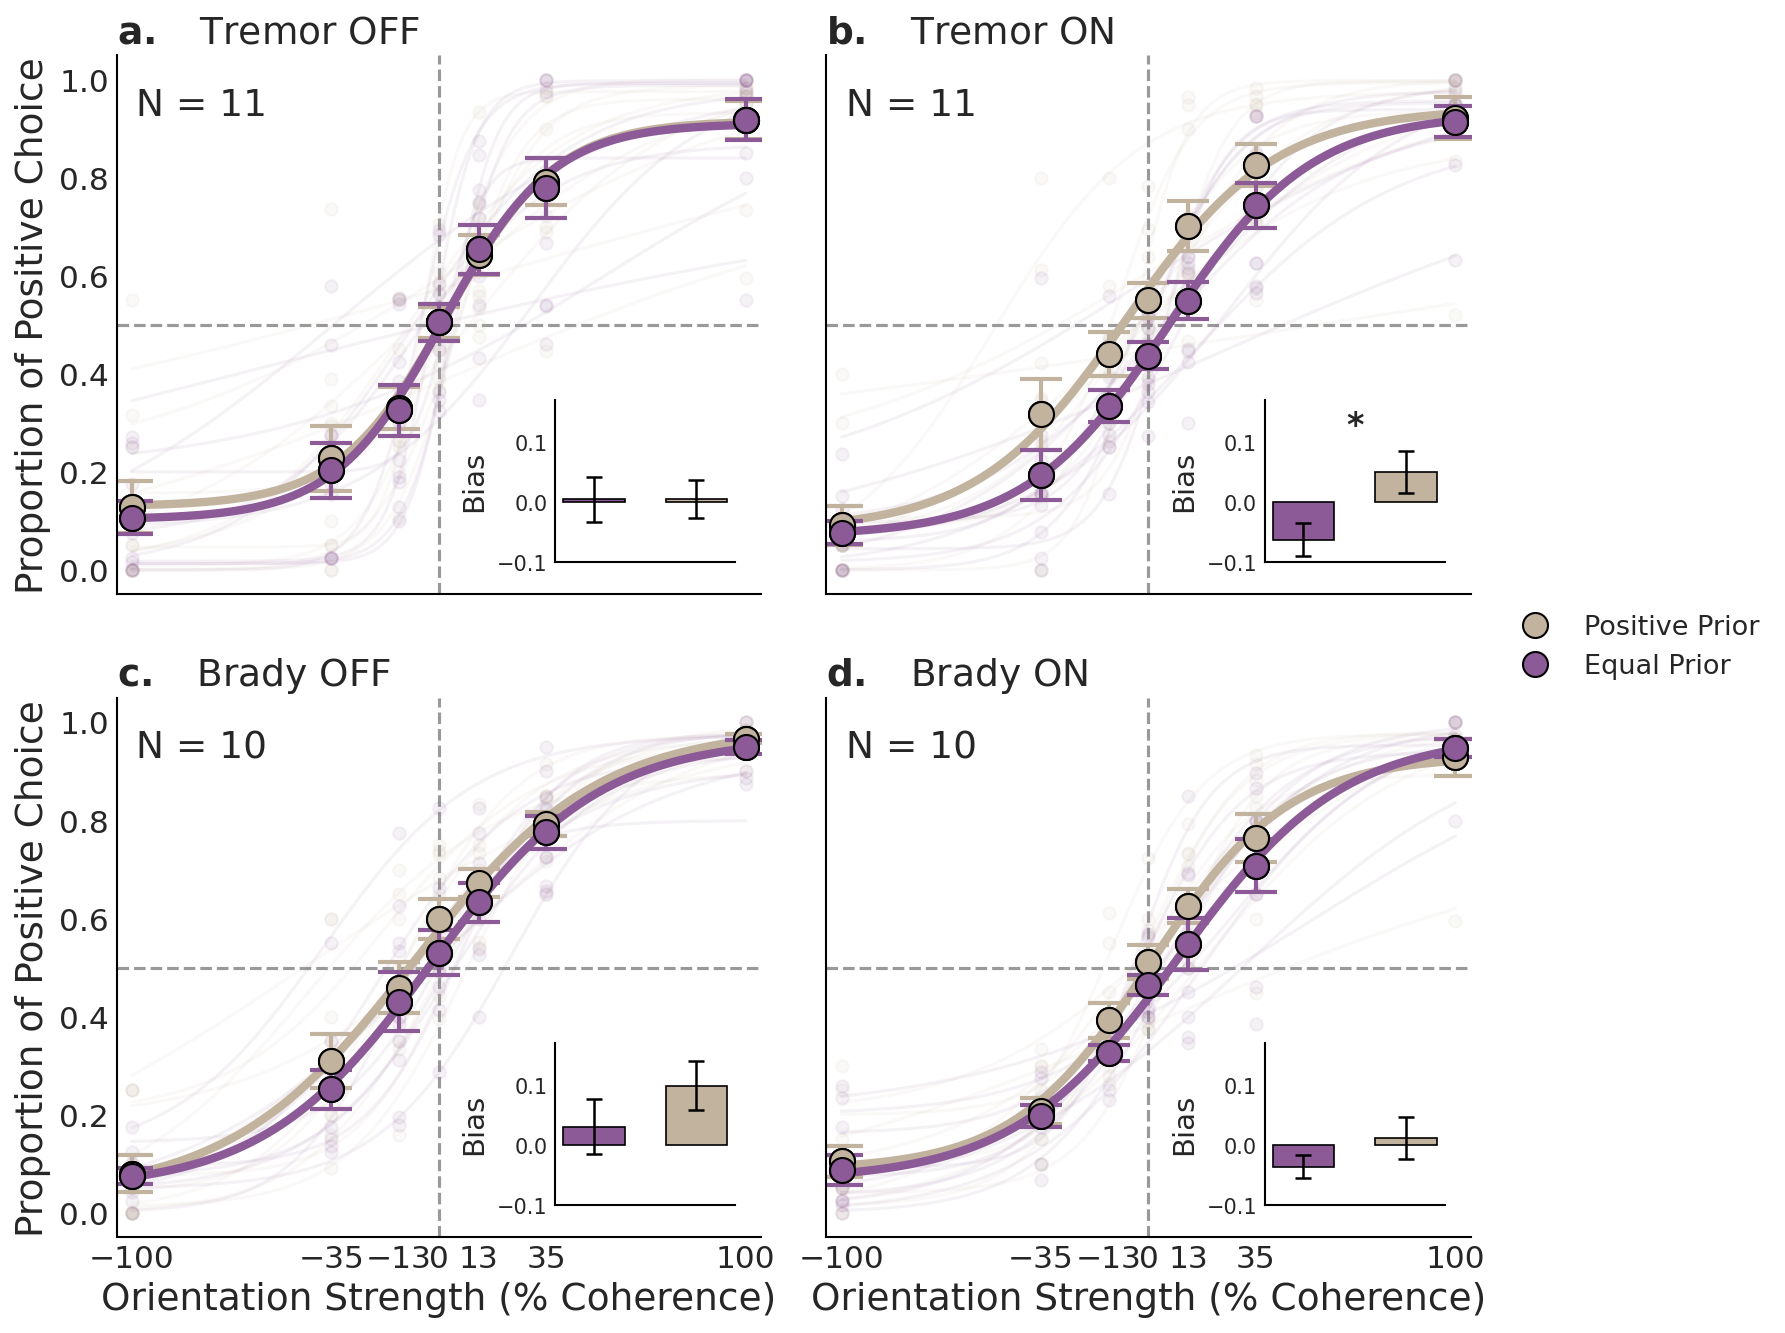

In [9]:
subtype_panels = [
    {"grp": "tremor_off", "sub_ids": subjects_map["tremor_dominant"], "med": "off", "title": "Tremor OFF"},
    {"grp": "tremor_on", "sub_ids": subjects_map["tremor_dominant"], "med": "on", "title": "Tremor ON"},
    {"grp": "brady_off", "sub_ids": subjects_map["bradykinesia_dominant"], "med": "off", "title": "Brady OFF"},
    {"grp": "brady_on", "sub_ids": subjects_map["bradykinesia_dominant"], "med": "on", "title": "Brady ON"},
]
subtype_letters = ["a.", "b.", "c.", "d."]
subtype_corrected_p = bias_significance(subtype_panels)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
axes = axes.flatten()
for ax, panel, letter in zip(axes, subtype_panels, subtype_letters):
    plot_curve_bias_panel(
        ax,
        panel["sub_ids"],
        panel["med"],
        panel["grp"],
        panel["title"],
        letter,
        subtype_corrected_p[panel["title"]],
        inset_ylim=(-0.10, 0.17),
    )

axes[0].set_ylabel("Proportion of Positive Choice", fontsize=18)
axes[2].set_ylabel("Proportion of Positive Choice", fontsize=18)
for i in [0,1]:
    axes[i].set_xticklabels([])
    axes[i].set_xlabel("")
axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.2), fontsize=13, frameon=False)
fig.tight_layout()


# Trial-level mixed-effects model (GLMM)

The DiD tests above collapse each subject/medication/prior condition down to one fitted `bias` number, then run a paired Wilcoxon signed-rank test across subjects. That throws away all trial-level information, so with only n=11 (tremor) or n=10 (brady) subjects the DiD (interaction) test is underpowered even when the underlying effect is real — e.g. Tremor showed a highly significant prior effect *at ON* (p=0.0068) sitting right next to a null effect *at OFF* (p=0.83), yet the interaction test of those two only reached p=0.147.

Here we instead fit a **trial-level mixed-effects logistic regression** directly on single-trial choices:

`choice ~ coherence + color * medication`, with a **maximal by-subject random-effects structure** — random intercept + random slopes for `color`, `medication`, and their interaction (`statsmodels.BinomialBayesMixedGLM`, since raw trial counts run into the tens of thousands, plain `MixedLM` only supports Gaussian outcomes, and no R/`lme4`/`pymer4` is available in this environment).

- `color` (prior: positive=+0.5 / equal=−0.5) and `medication` (on=+0.5 / off=−0.5) are effect-coded so the `color:medication` coefficient is a clean interaction term — this is the trial-level analog of the DiD estimate above.
- `coherence` (scaled to ±1) is included as a fixed-effect covariate to soak up the psychometric slope, so the intercept-side terms isolate the *bias* (choice at zero coherence), matching what `bias` measured in the subject-level analysis.
- Random *slopes* (not just a random intercept) for `color`, `medication`, and `color:medication` per subject are essential here, not optional: with only a random intercept, the model could mistake genuine between-subject variability in how much medication changes prior-use for residual trial noise, understating uncertainty on the fixed-effect interaction (pseudoreplication). With the full structure, each subject is allowed their own slope, and the fixed-effect interaction represents the population-average slope after that variability is accounted for.

In [10]:
from scipy import stats as scipy_stats

# Subject-level DiD scores (positive-vs-equal bias, ON minus OFF), needed by the GLMM
# comparison below. Computed silently here — the DiD figures themselves live in 2.20.
did_group_order = ["tremor", "brady"]
did_group_titles = {"tremor": "Tremor Dominant", "brady": "Brady Dominant"}

did_results = {}
for grp in did_group_order:
    off_idx, on_idx = grp_indices[f"{grp}_off"], grp_indices[f"{grp}_on"]
    prior_effect_off = psych_params.loc[off_idx, "positive_bias"].to_numpy() - psych_params.loc[off_idx, "equal_bias"].to_numpy()
    prior_effect_on = psych_params.loc[on_idx, "positive_bias"].to_numpy() - psych_params.loc[on_idx, "equal_bias"].to_numpy()
    did_results[("bias", grp)] = prior_effect_on - prior_effect_off


In [11]:
did_group_subjects = {
    "pd": subjects_map["all"],
    "tremor": subjects_map["tremor_dominant"],
    "brady": subjects_map["bradykinesia_dominant"],
}


def fit_trial_level_glmm(trial_data, subject_ids):
    """Fit choice ~ coherence + color * medication with a full by-subject random-effects structure
    (random intercept + random slopes for color, medication, and their interaction)."""
    df = trial_data[trial_data["subject_id"].isin(subject_ids) & trial_data["medication"].isin(["off", "on"])].copy()
    df["coh_scaled"] = df["signed_coherence"] / 100.0
    df["color_c"] = df["color"] - 0.5
    df["med_c"] = (df["medication"] == "on").astype(float) - 0.5

    model = sm.BinomialBayesMixedGLM.from_formula(
        "choice ~ coh_scaled + color_c * med_c",
        vc_formulas={
            "subject_intercept": "0 + C(subject_id)",
            "subject_color": "0 + C(subject_id):color_c",
            "subject_med": "0 + C(subject_id):med_c",
            "subject_colormed": "0 + C(subject_id):color_c:med_c",
        },
        data=df,
    )
    result = model.fit_vb()
    return result, df


glmm_results = {}
glmm_fits = {}
for grp in did_group_order:
    result, df = fit_trial_level_glmm(filtered_data, did_group_subjects[grp])
    glmm_fits[grp] = result

    fe_names = result.model.exog_names
    means = pd.Series(result.fe_mean, index=fe_names)
    sds = pd.Series(result.fe_sd, index=fe_names)

    term = "color_c:med_c"
    z = means[term] / sds[term]
    p = 2 * (1 - stats.norm.cdf(np.abs(z)))
    glmm_results[grp] = {"n_subjects": df["subject_id"].nunique(), "n_trials": len(df), "estimate": means[term], "sd": sds[term], "z": z, "p": p}

    print(f"-- {did_group_titles[grp]} (n_subjects={glmm_results[grp]['n_subjects']}, n_trials={glmm_results[grp]['n_trials']}) --")
    print(f"color:medication interaction: est={means[term]:.4f} +/- {sds[term]:.4f}, z={z:.3f}, p={p:.4g}")
    print()

-- Tremor Dominant (n_subjects=11, n_trials=13540) --
color:medication interaction: est=0.4706 +/- 0.0814, z=5.780, p=7.485e-09

-- Brady Dominant (n_subjects=10, n_trials=12549) --
color:medication interaction: est=0.0084 +/- 0.0853, z=0.098, p=0.9218



### Subject-level DiD vs. trial-level GLMM

In [12]:
comparison_rows = []
for grp in did_group_order:
    wilcoxon_p = scipy_stats.wilcoxon(did_results[("bias", grp)]).pvalue
    g = glmm_results[grp]
    comparison_rows.append(
        {
            "group": did_group_titles[grp],
            "n_subjects": g["n_subjects"],
            "n_trials": g["n_trials"],
            "wilcoxon_DiD_p (subject-level)": wilcoxon_p,
            "GLMM_interaction_p (trial-level)": g["p"],
            "GLMM_z": g["z"],
        }
    )

comparison_df = pd.DataFrame(comparison_rows).set_index("group")
comparison_df.round(4)

                 n_subjects  n_trials  wilcoxon_DiD_p (subject-level)  \
group                                                                   
Tremor Dominant          11     13540                          0.1475   
Brady Dominant           10     12549                          0.8457   

                 GLMM_interaction_p (trial-level)  GLMM_z  
group                                                      
Tremor Dominant                            0.0000  5.7797  
Brady Dominant                             0.9218  0.0982  

### Interaction plot (model-predicted, trial-level)

Same layout as the earlier interaction plot, but the OFF/ON points are the GLMM's fixed-effects-only predicted choice probability at 0% coherence (i.e. the model's bias estimate), with 95% CIs from the posterior SDs of the fixed effects (mean-field VB, so these treat the fixed effects as independent — a reasonable approximation here, but not exact).

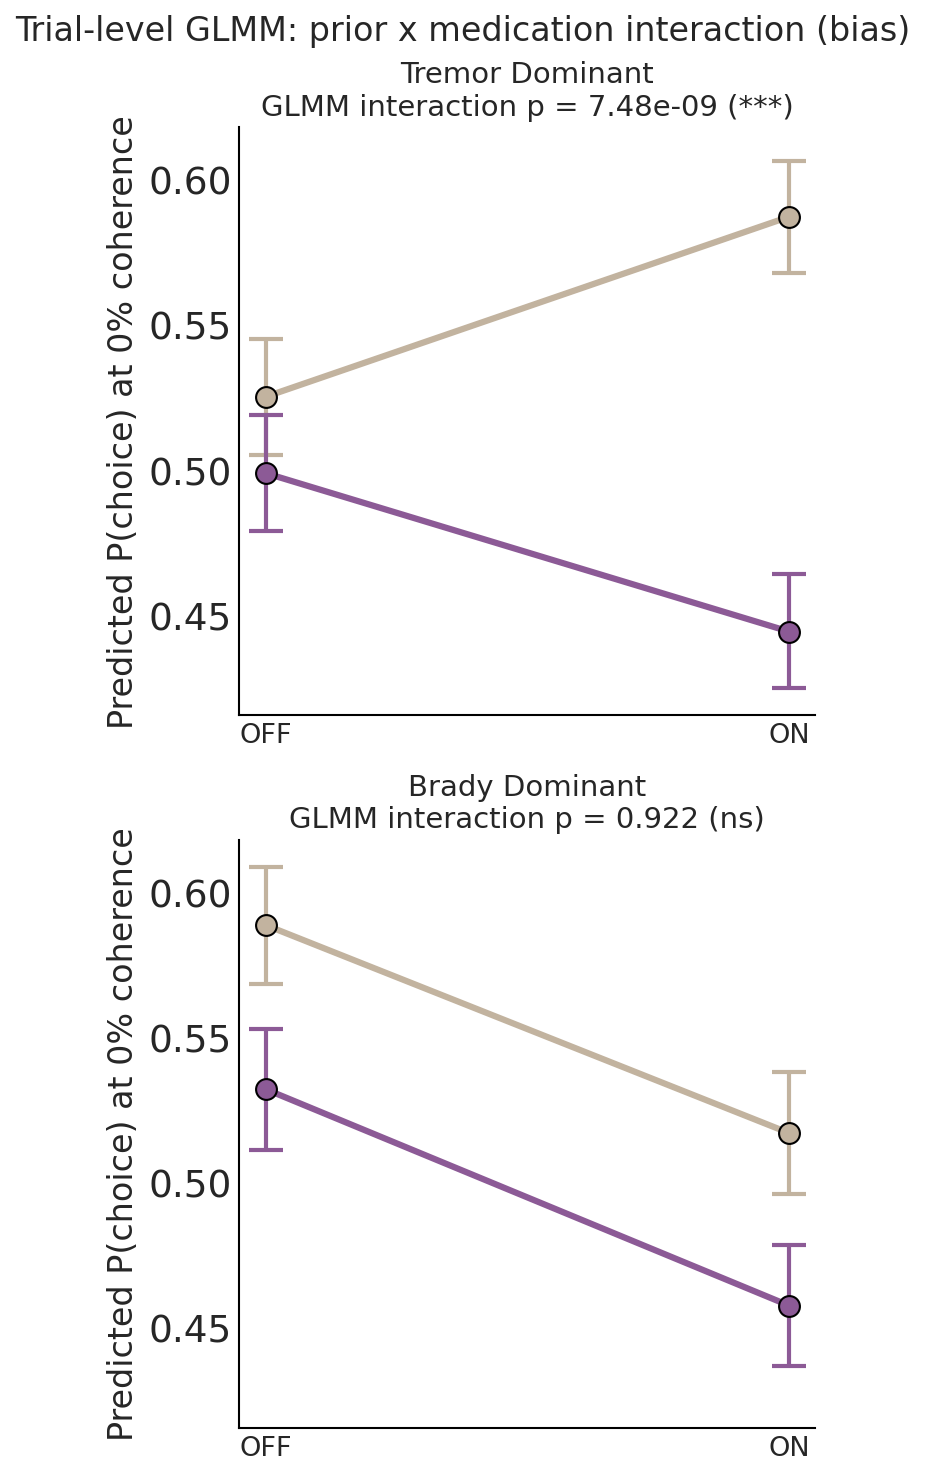

In [13]:
def predicted_prob_at_zero_coherence(result, color_val, med_val):
    """Fixed-effects-only predicted P(choice) at coh_scaled=0, with a 95% CI from the mean-field posterior SDs."""
    fe_names = result.model.exog_names
    means = pd.Series(result.fe_mean, index=fe_names)
    sds = pd.Series(result.fe_sd, index=fe_names)

    logit_mean = means["Intercept"] + means["color_c"] * color_val + means["med_c"] * med_val + means["color_c:med_c"] * color_val * med_val
    logit_var = sds["Intercept"] ** 2 + (color_val * sds["color_c"]) ** 2 + (med_val * sds["med_c"]) ** 2 + (color_val * med_val * sds["color_c:med_c"]) ** 2
    logit_sd = np.sqrt(logit_var)

    sigmoid = lambda z: 1 / (1 + np.exp(-z))  # noqa: E731
    return sigmoid(logit_mean), sigmoid(logit_mean - 1.96 * logit_sd), sigmoid(logit_mean + 1.96 * logit_sd)


err_style = {"elinewidth": 2, "capsize": 8, "capthick": 2}

fig, axes = plt.subplots(2, 1, figsize=(5, 10), sharey=True)
for ax, grp in zip(axes, did_group_order):

    result = glmm_fits[grp]
    x = np.array([0, 1])
    for key, color_val, color, label in [("positive", 0.5, pos_color, "Positive Prior"), ("equal", -0.5, eq_color, "Equal Prior")]:
        preds = [predicted_prob_at_zero_coherence(result, color_val, med_val) for med_val in (-0.5, 0.5)]
        probs = np.array([p[0] for p in preds])
        lo = np.array([p[1] for p in preds])
        hi = np.array([p[2] for p in preds])
        yerr = np.vstack([probs - lo, hi - probs])
        ax.errorbar(x, probs, yerr=yerr, color=color, marker="o", ms=10, mec="k", lw=3, label=label, **err_style)

    g = glmm_results[grp]
    star = "***" if g["p"] < 0.001 else "**" if g["p"] < 0.01 else "*" if g["p"] < 0.05 else "ns"
    ax.set_xticks(x)
    ax.set_xticklabels(["OFF", "ON"], fontsize=13)
    ax.set_title(f"{did_group_titles[grp]}\nGLMM interaction p = {g['p']:.3g} ({star})", fontsize=14)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

axes[0].set_ylabel("Predicted P(choice) at 0% coherence")
axes[1].set_ylabel("Predicted P(choice) at 0% coherence")

# axes[0].legend(frameon=False)
fig.suptitle("Trial-level GLMM: prior x medication interaction (bias)", fontsize=16)
fig.tight_layout()
plt.show()

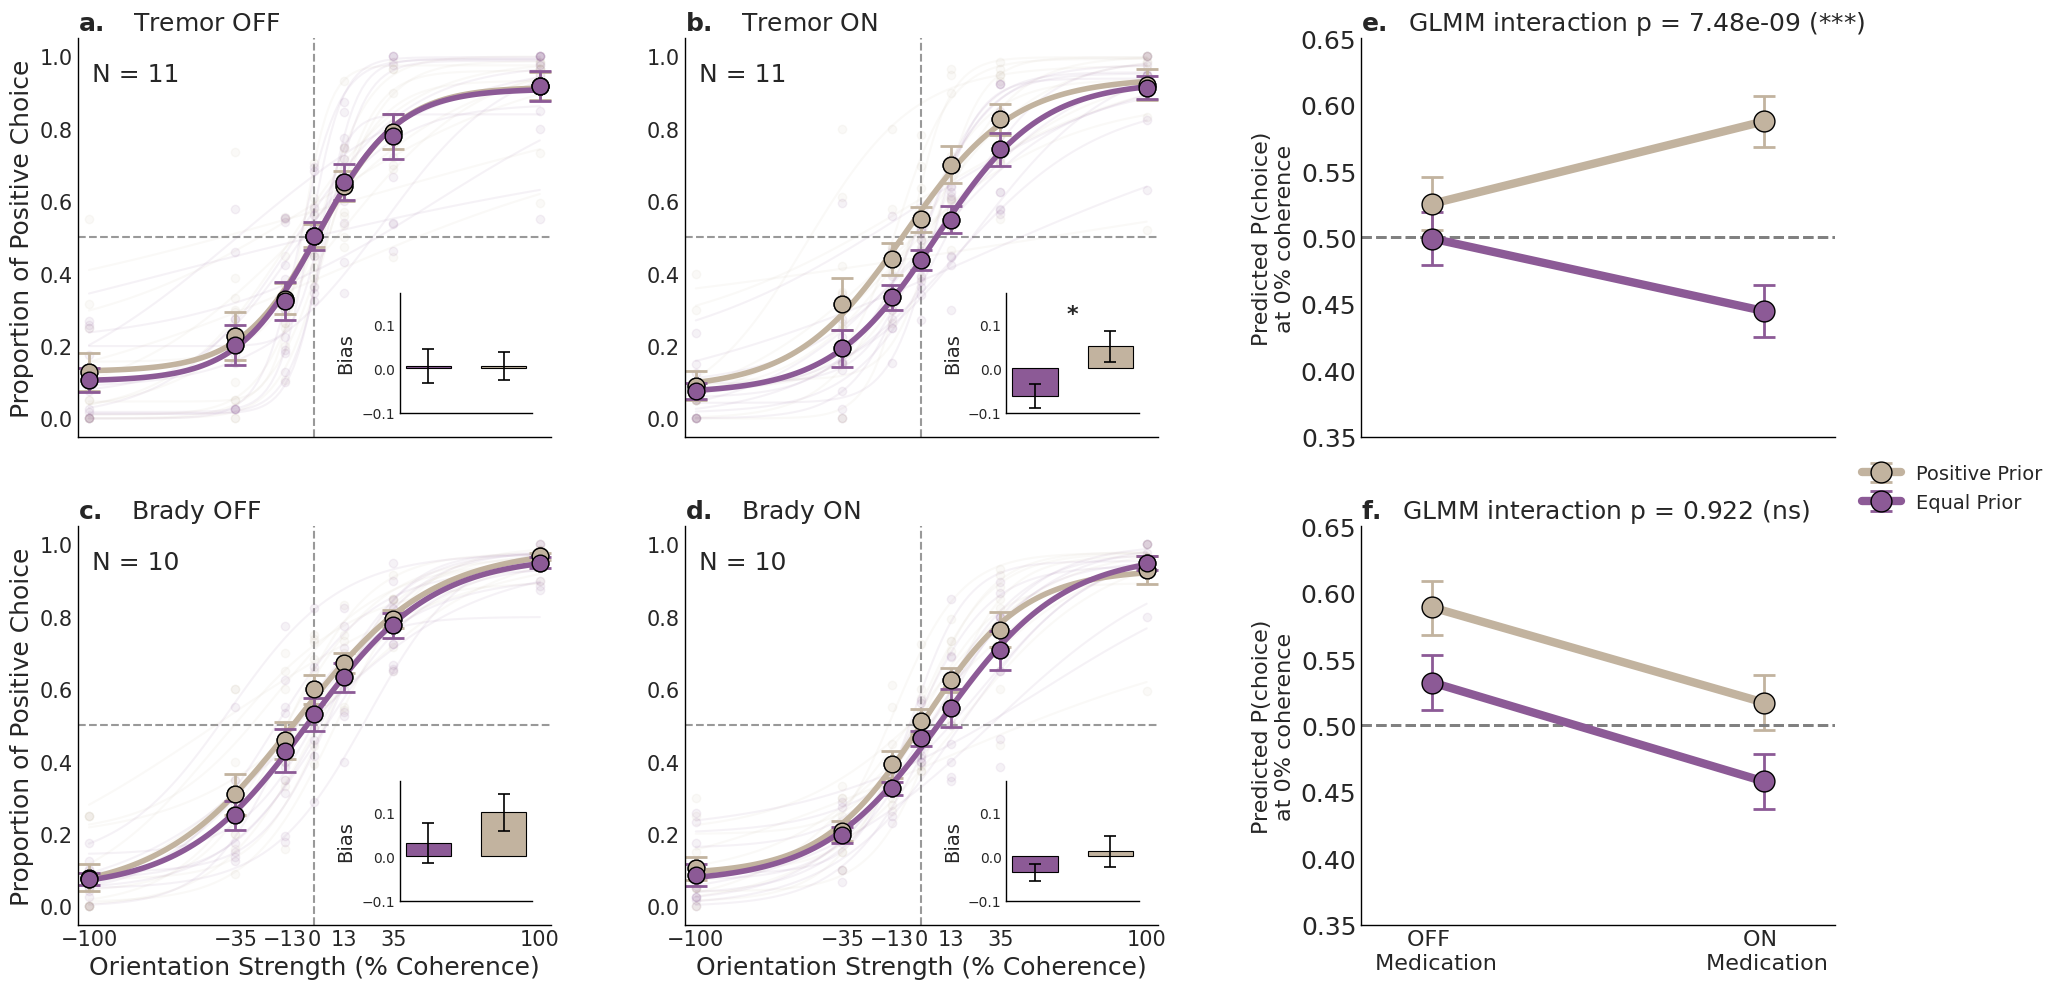

In [123]:
subtype_panels = [
    {"grp": "tremor_off", "sub_ids": subjects_map["tremor_dominant"], "med": "off", "title": "Tremor OFF"},
    {"grp": "tremor_on", "sub_ids": subjects_map["tremor_dominant"], "med": "on", "title": "Tremor ON"},
    {"grp": "brady_off", "sub_ids": subjects_map["bradykinesia_dominant"], "med": "off", "title": "Brady OFF"},
    {"grp": "brady_on", "sub_ids": subjects_map["bradykinesia_dominant"], "med": "on", "title": "Brady ON"},
]
subtype_letters = ["a.", "b.", "c.", "d."]
glmm_letters = ["e.", "f."]
subtype_corrected_p = bias_significance(subtype_panels)

fig, axs = plt.subplots(2, 3, figsize=(20, 10))
axs = axs.flatten()
curve_axes = [axs[0], axs[1], axs[3], axs[4]]
glmm_axes = [axs[2], axs[5]]

for ax, panel, letter in zip(curve_axes, subtype_panels, subtype_letters):
    plot_curve_bias_panel(
        ax,
        panel["sub_ids"],
        panel["med"],
        panel["grp"],
        panel["title"],
        letter,
        subtype_corrected_p[panel["title"]],
        inset_ylim=(-0.10, 0.17),
    )

curve_axes[0].set_ylabel("Proportion of Positive Choice", fontsize=18)
curve_axes[2].set_ylabel("Proportion of Positive Choice", fontsize=18)
curve_axes[0].set_xticklabels([])
curve_axes[0].set_xlabel("")
curve_axes[1].set_xticklabels([])
curve_axes[1].set_xlabel("")

for ax, grp, letter in zip(glmm_axes, ("tremor", "brady"), glmm_letters):
    result = glmm_fits[grp]
    x = np.array([0.15, .85])
    for key, color_val, color, label in [("positive", 0.5, pos_color, "Positive Prior"), ("equal", -0.5, eq_color, "Equal Prior")]:
        preds = [predicted_prob_at_zero_coherence(result, color_val, med_val) for med_val in (-0.5, 0.5)]
        probs = np.array([p[0] for p in preds])
        lo = np.array([p[1] for p in preds])
        hi = np.array([p[2] for p in preds])
        yerr = np.vstack([probs - lo, hi - probs])
        ax.errorbar(x, probs, yerr=yerr, color=color, marker="o", ms=15, mec="k", lw=6, label=label, **err_style)
        ax.axhline(0.5, color="gray", lw=2, linestyle="--")


    g = glmm_results[grp]
    star = "***" if g["p"] < 0.001 else "**" if g["p"] < 0.01 else "*" if g["p"] < 0.05 else "ns"
    if grp == "brady":
        ax.set_xticklabels(["OFF \n Medication", "ON \n Medication"], fontsize=16)
    else:
        ax.set_xticklabels([])
    ax.set_xlim([0, 1])
    ax.set_xticks(x)
    ax.set_ylim([.35, .65])
    ax.set_title(rf"$\mathbf{{{letter}}}$  " + f"GLMM interaction p = {g['p']:.3g} ({star})", loc="left", fontsize=18)
    ax.set_ylabel("Predicted P(choice)\nat 0% coherence")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

glmm_axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.2), fontsize=14, frameon=False)

fig.tight_layout()

# nudge the GLMM column right for a bit of visual separation from the curve panels
column_gap = 0.035
for ax in glmm_axes:
    pos = ax.get_position()
    ax.set_position([pos.x0 + column_gap, pos.y0, pos.width, pos.height])


In [ ]:
subtype_panels = [
    {"grp": "tremor_off", "sub_ids": subjects_map["tremor_dominant"], "med": "off", "title": "Tremor OFF"},
    {"grp": "tremor_on", "sub_ids": subjects_map["tremor_dominant"], "med": "on", "title": "Tremor ON"},
    {"grp": "brady_off", "sub_ids": subjects_map["bradykinesia_dominant"], "med": "off", "title": "Brady OFF"},
    {"grp": "brady_on", "sub_ids": subjects_map["bradykinesia_dominant"], "med": "on", "title": "Brady ON"},
]
subtype_letters = ["a.", "b.", "c.", "d."]
glmm_letters = ["e.", "f."]
subtype_corrected_p = bias_significance(subtype_panels)

fig, axs = plt.subplots(2, 3, figsize=(20, 10))
axs = axs.flatten()
curve_axes = [axs[0], axs[1], axs[3], axs[4]]
glmm_axes = [axs[2], axs[5]]

for ax, panel, letter in zip(curve_axes, subtype_panels, subtype_letters):
    plot_curve_bias_panel(
        ax,
        panel["sub_ids"],
        panel["med"],
        panel["grp"],
        panel["title"],
        letter,
        subtype_corrected_p[panel["title"]],
        inset_ylim=(-0.10, 0.17),
    )

curve_axes[0].set_ylabel("Proportion of Positive Choice", fontsize=18)
curve_axes[2].set_ylabel("Proportion of Positive Choice", fontsize=18)
curve_axes[0].set_xticklabels([])
curve_axes[0].set_xlabel("")
curve_axes[1].set_xticklabels([])
curve_axes[1].set_xlabel("")

for ax, grp, letter in zip(glmm_axes, ("tremor", "brady"), glmm_letters):
    result = glmm_fits[grp]
    x = np.array([0.15, 0.85])
    for key, color_val, color, label in [("positive", 0.5, pos_color, "Positive Prior"), ("equal", -0.5, eq_color, "Equal Prior")]:
        preds = [predicted_prob_at_zero_coherence(result, color_val, med_val) for med_val in (-0.5, 0.5)]
        probs = np.array([p[0] for p in preds])
        lo = np.array([p[1] for p in preds])
        hi = np.array([p[2] for p in preds])
        yerr = np.vstack([probs - lo, hi - probs])
        ax.errorbar(x, probs, yerr=yerr, color=color, marker="o", ms=15, mec="k", lw=6, label=label, **err_style)
        ax.axhline(0.5, color="gray", lw=2, linestyle="--")

    g = glmm_results[grp]
    star = "***" if g["p"] < 0.001 else "**" if g["p"] < 0.01 else "*" if g["p"] < 0.05 else "ns"
    if grp == "brady":
        ax.set_xticklabels(["OFF \n Medication", "ON \n Medication"], fontsize=16)
    else:
        ax.set_xticklabels([])
    ax.set_xlim([0, 1])
    ax.set_xticks(x)
    ax.set_ylim([0.35, 0.65])
    ax.set_title(rf"$\mathbf{{{letter}}}$  " + f"GLMM interaction p = {g['p']:.3g} ({star})", loc="left", fontsize=18)
    ax.set_ylabel("Predicted P(choice)\nat 0% coherence")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

glmm_axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.2), fontsize=14, frameon=False)

fig.tight_layout()

# nudge the GLMM column right for a bit of visual separation from the curve panels
column_gap = 0.035
for ax in glmm_axes:
    pos = ax.get_position()
    ax.set_position([pos.x0 + column_gap, pos.y0, pos.width, pos.height])


### Leave-one-subject-out sensitivity check

The GLMM correctly extracts more signal from each subject's trials than collapsing to one summary number, but it can't manufacture information about between-subject *heterogeneity* that isn't there — with only 11 (tremor) or 10 (brady) subjects, a single outlier could in principle be driving the whole population-level interaction. To check, refit the model once per subject with that subject held out, and see whether the `color:medication` estimate stays consistently on the same side of zero and significant.

("All PD", n=41, is skipped here — the full model alone takes ~15s to fit, so a 41-fold refit is expensive; the subtype-level results are the ones the interaction claim rests on anyway.)

In [15]:
def leave_one_subject_out(trial_data, subject_ids):
    """Refit the trial-level GLMM once per subject, holding that subject out each time."""
    rows = []
    for held_out in subject_ids:
        remaining = [s for s in subject_ids if s != held_out]
        result, _ = fit_trial_level_glmm(trial_data, remaining)

        fe_names = result.model.exog_names
        means = pd.Series(result.fe_mean, index=fe_names)
        sds = pd.Series(result.fe_sd, index=fe_names)
        term = "color_c:med_c"
        z = means[term] / sds[term]
        p = 2 * (1 - stats.norm.cdf(np.abs(z)))
        rows.append({"held_out_subject": held_out, "estimate": means[term], "sd": sds[term], "p": p})
    return pd.DataFrame(rows)


loso_results = {}
for grp in ["tremor", "brady"]:
    print(f"Leave-one-subject-out: {did_group_titles[grp]} ({len(did_group_subjects[grp])} refits)...")
    loso_results[grp] = leave_one_subject_out(filtered_data, did_group_subjects[grp])
    n_flips = (loso_results[grp]["p"] >= 0.05).sum()
    n_sign_flips = (np.sign(loso_results[grp]["estimate"]) != np.sign(glmm_results[grp]["estimate"])).sum()
    print(f"  full-sample estimate={glmm_results[grp]['estimate']:.4f} (p={glmm_results[grp]['p']:.3g})")
    print(f"  exclusions that drop below p<0.05: {n_flips}/{len(loso_results[grp])}; sign flips: {n_sign_flips}/{len(loso_results[grp])}")
    print()

Leave-one-subject-out: Tremor Dominant (11 refits)...
  full-sample estimate=0.4706 (p=7.48e-09)
  exclusions that drop below p<0.05: 0/11; sign flips: 0/11

Leave-one-subject-out: Brady Dominant (10 refits)...
  full-sample estimate=0.0084 (p=0.922)
  exclusions that drop below p<0.05: 10/10; sign flips: 5/10



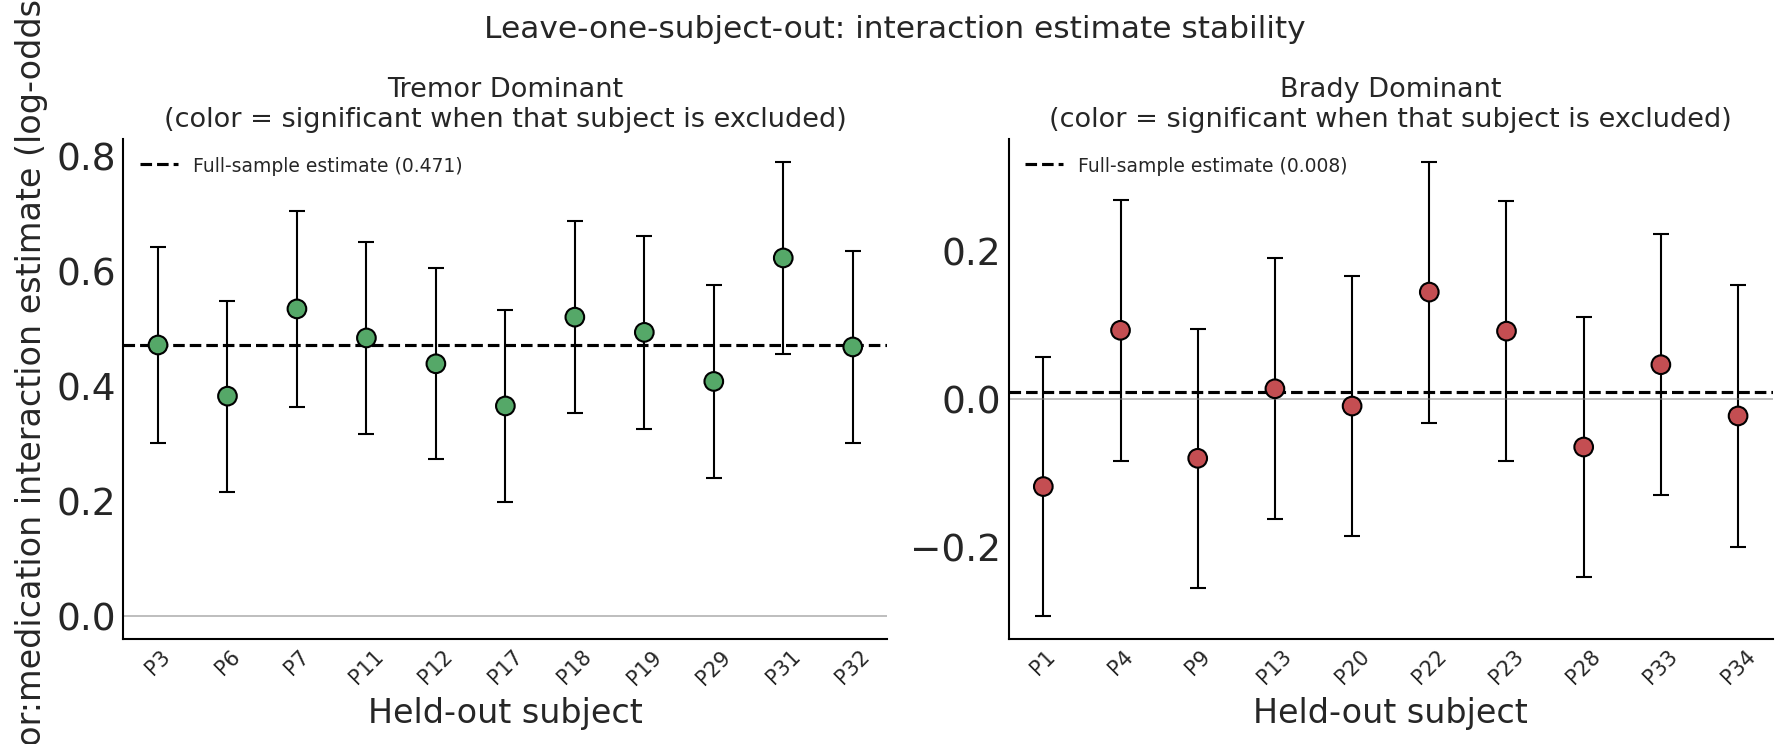

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, grp in zip(axes, ["tremor", "brady"]):
    loso = loso_results[grp]
    full_est = glmm_results[grp]["estimate"]
    point_colors = ["#C44E52" if p >= 0.05 else "#55A868" for p in loso["p"]]

    x = np.arange(len(loso))
    ax.errorbar(x, loso["estimate"], yerr=1.96 * loso["sd"], fmt="none", color="k", elinewidth=1, capsize=4, zorder=2)
    ax.scatter(x, loso["estimate"], c=point_colors, s=80, edgecolor="k", zorder=3)
    ax.axhline(full_est, color="k", ls="--", lw=1.5, label=f"Full-sample estimate ({full_est:.3f})")
    ax.axhline(0, color="gray", lw=0.8, alpha=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels(loso["held_out_subject"], rotation=45, fontsize=10)
    ax.set_xlabel("Held-out subject")
    ax.set_title(f"{did_group_titles[grp]}\n(color = significant when that subject is excluded)", fontsize=13)
    ax.legend(frameon=False, fontsize=9, loc="best")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

axes[0].set_ylabel("color:medication interaction estimate (log-odds)")
fig.suptitle("Leave-one-subject-out: interaction estimate stability", fontsize=15)
fig.tight_layout()
plt.show()